# AI-assisted Network Monitoring and Recovery on FABRIC

This notebook builds a **new FABRIC project experiment** with a real lightweight local AI agent.

Goal:

1. Build a small routed topology on FABRIC.
2. Monitor latency, packet loss, and throughput.
3. Simulate congestion on the direct route using Linux `tc netem`.
4. Let a local ML-based AI agent switch traffic to a backup route.
5. When the direct route recovers, let the agent restore the shorter optimal route.

The design follows the same FABRIC workflow as the tutorial: create/load FABRIC config, reserve resources, configure interfaces/routes, draw topology, use SSH/remote commands, run `ping`, and clean up the slice when finished.

## Topology

Normal direct route:

```text
client -> r1 -> r2 -> server
```

Backup route:

```text
client -> r1 -> r3 -> r2 -> server
```

The direct route is shorter, so it is preferred when healthy. The backup route is longer, but it avoids the degraded `r1 <-> r2` link during congestion.

## AI agent choice

This notebook uses a **local supervised ML agent** based on `scikit-learn` Random Forest.

Why this model:

- It is lightweight and can run locally in the FABRIC Jupyter environment.
- It does not need an external API key.
- It is more reliable than a tiny local LLM for a control decision that should return one of a few valid actions.
- It still counts as a real AI/ML agent because it learns a decision boundary from training examples and performs model inference during the control loop.

The agent observes this feature vector:

```text
current_path_backup, end_to_end_RTT, end_to_end_loss, throughput,
direct_link_probe_RTT, direct_link_probe_loss, direct_healthy_streak
```

It predicts one action:

```text
KEEP_DIRECT
SWITCH_TO_BACKUP
KEEP_BACKUP
RESTORE_DIRECT
```

## 0. Install/import local project code

Run this cell from the project folder. The `src/ai_agent.py` file contains the local ML agent.

In [1]:
import sys, os, time, re, json, subprocess
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

try:
    import sklearn
except ImportError:
    print("Installing scikit-learn and joblib in the Jupyter environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "joblib", "pandas", "matplotlib", "networkx"])

from ai_agent import LocalNetworkAIAgent, Observation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib


## 1. Load FABRIC configuration

This assumes your FABRIC Jupyter environment is already configured using the tutorial setup. If this fails, first run the configuration cells from the `hello_fabric` tutorial.

In [2]:
%env FABRIC_BASTION_USERNAME sonvu_0000467821
%env FABRIC_PROJECT_ID 5268932f-7bf8-4418-9dbb-1f53dcea5a6b

env: FABRIC_BASTION_USERNAME=sonvu_0000467821
env: FABRIC_PROJECT_ID=5268932f-7bf8-4418-9dbb-1f53dcea5a6b


In [3]:
from fabrictestbed_extensions.fablib.fablib import FablibManager as fablib_manager
fablib = fablib_manager()
conf = fablib.show_config()

User: sonvu@umass.edu bastion key is valid!
Configuration is valid


Credential Manager,cm.fabric-testbed.net
Orchestrator,orchestrator.fabric-testbed.net
Project ID,5268932f-7bf8-4418-9dbb-1f53dcea5a6b
Token File,/home/fabric/.tokens.json
Bastion Host,bastion.fabric-testbed.net
Bastion Username,sonvu_0000467821
Bastion Private Key File,/home/fabric/work/fabric_config/fabric_bastion_key
Slice Private Key File,/home/fabric/work/fabric_config/slice_key
Slice Public Key File,/home/fabric/work/fabric_config/slice_key.pub
Log File,/tmp/fablib/fablib.log
Log Level,INFO


## 2. Define the FABRIC experiment

This creates five Ubuntu VMs with basic NICs. You can change `site_name` if the selected site does not have resources available.

In [4]:
slice_name = "ai-mcp-recovery-" + fablib.get_bastion_username()
site_name = "MAX"  # change if needed

node_conf = [
    {'name': "client", 'cores': 2, 'ram': 4, 'disk': 10, 'image': 'default_ubuntu_22', 'packages': ['net-tools', 'iperf3', 'iproute2']},
    {'name': "server", 'cores': 2, 'ram': 4, 'disk': 10, 'image': 'default_ubuntu_22', 'packages': ['net-tools', 'iperf3', 'iproute2']},
    {'name': "r1",     'cores': 2, 'ram': 4, 'disk': 10, 'image': 'default_ubuntu_22', 'packages': ['net-tools', 'iperf3', 'iproute2']},
    {'name': "r2",     'cores': 2, 'ram': 4, 'disk': 10, 'image': 'default_ubuntu_22', 'packages': ['net-tools', 'iperf3', 'iproute2']},
    {'name': "r3",     'cores': 2, 'ram': 4, 'disk': 10, 'image': 'default_ubuntu_22', 'packages': ['net-tools', 'iperf3', 'iproute2']},
]

net_conf = [
    {"name": "net_client_r1", "subnet": "10.10.0.0/24", "nodes": [{"name": "client", "addr": "10.10.0.2"}, {"name": "r1", "addr": "10.10.0.1"}]},
    {"name": "net_r1_r2",     "subnet": "10.10.1.0/24", "nodes": [{"name": "r1", "addr": "10.10.1.1"}, {"name": "r2", "addr": "10.10.1.2"}]},
    {"name": "net_r2_server", "subnet": "10.10.2.0/24", "nodes": [{"name": "r2", "addr": "10.10.2.1"}, {"name": "server", "addr": "10.10.2.2"}]},
    {"name": "net_r1_r3",     "subnet": "10.10.3.0/24", "nodes": [{"name": "r1", "addr": "10.10.3.1"}, {"name": "r3", "addr": "10.10.3.2"}]},
    {"name": "net_r3_r2",     "subnet": "10.10.4.0/24", "nodes": [{"name": "r3", "addr": "10.10.4.1"}, {"name": "r2", "addr": "10.10.4.2"}]},
]

SERVER_IP = "10.10.2.2"
CLIENT_IP = "10.10.0.2"
R2_DIRECT_IP = "10.10.1.2"

print("Slice:", slice_name)
print("Site:", site_name)
fablib.show_site(site_name)

Slice: ai-mcp-recovery-sonvu_0000467821
Site: MAX


Name,MAX
State,Active
Address,"4161 Fieldhouse Drive,College Park,MD 20742"
Location,"(38.9886345, -76.9434794)"
PTP Capable,True
Hosts,5
CPUs,10
Cores Available,136
Cores Capacity,640
Cores Allocated,504
Ram Available,1510


'<pandas.io.formats.style.Styler object at 0x7aac1c5e7c50>'

## 3. Reserve resources

If a slice with the same name already exists, the notebook will reuse it.

In [5]:
try:
    slice = fablib.get_slice(slice_name)
    print("Reusing existing slice:", slice_name)
except Exception:
    print("Creating new slice:", slice_name)
    slice = fablib.new_slice(name=slice_name)

    for n in node_conf:
        slice.add_node(name=n['name'], site=site_name,
                       cores=n['cores'], ram=n['ram'], disk=n['disk'], image=n['image'])

    for net in net_conf:
        ifaces = []
        for node in net['nodes']:
            iface = slice.get_node(node["name"]).add_component(
                model="NIC_Basic", name=net["name"]
            ).get_interfaces()[0]
            ifaces.append(iface)
        slice.add_l2network(name=net["name"], type='L2Bridge', interfaces=ifaces)

    slice.submit()

slice.update()
_ = slice.show()


Retry: 10, Time: 295 sec


ID,392a5c13-c63e-41c7-bd20-eda54a60d039
Name,ai-mcp-recovery-sonvu_0000467821
Lease Expiration (UTC),2026-05-14 15:04:20 +0000
Lease Start (UTC),2026-05-13 15:04:20 +0000
Project ID,5268932f-7bf8-4418-9dbb-1f53dcea5a6b
State,StableOK
Email,sonvu@umass.edu
UserId,4ad9cab5-c698-4bba-ab3e-6da8a1abca67


ID,Name,Cores,RAM,Disk,Image,Image Type,Host,Site,Username,Management IP,State,Error,SSH Command,Public SSH Key File,Private SSH Key File
d6381844-9030-41b8-a07a-22e409abfaa4,client,2,4,10,default_ubuntu_22,qcow2,max-w5.fabric-testbed.net,MAX,ubuntu,2001:468:c00:ffc4:f816:3eff:fe76:370a,Active,,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:468:c00:ffc4:f816:3eff:fe76:370a,/home/fabric/work/fabric_config/slice_key.pub,/home/fabric/work/fabric_config/slice_key
5c9c0703-9dba-4952-97ed-3245a939e9f8,r1,2,4,10,default_ubuntu_22,qcow2,max-w2.fabric-testbed.net,MAX,ubuntu,2001:468:c00:ffc4:f816:3eff:fe14:a21d,Active,,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:468:c00:ffc4:f816:3eff:fe14:a21d,/home/fabric/work/fabric_config/slice_key.pub,/home/fabric/work/fabric_config/slice_key
ab8ee489-5855-467b-83fd-8d977cf6d74c,r2,2,4,10,default_ubuntu_22,qcow2,max-w1.fabric-testbed.net,MAX,ubuntu,2001:468:c00:ffc4:f816:3eff:fe70:4931,Active,,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:468:c00:ffc4:f816:3eff:fe70:4931,/home/fabric/work/fabric_config/slice_key.pub,/home/fabric/work/fabric_config/slice_key
dbdcc993-1879-4d2e-adac-52d0cbaeee1e,r3,2,4,10,default_ubuntu_22,qcow2,max-w1.fabric-testbed.net,MAX,ubuntu,2001:468:c00:ffc4:f816:3eff:fe9c:73fc,Active,,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:468:c00:ffc4:f816:3eff:fe9c:73fc,/home/fabric/work/fabric_config/slice_key.pub,/home/fabric/work/fabric_config/slice_key
a21de0a0-40ff-43a3-8e12-84be4c489fb7,server,2,4,10,default_ubuntu_22,qcow2,max-w5.fabric-testbed.net,MAX,ubuntu,2001:468:c00:ffc4:f816:3eff:fe5b:643c,Active,,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:468:c00:ffc4:f816:3eff:fe5b:643c,/home/fabric/work/fabric_config/slice_key.pub,/home/fabric/work/fabric_config/slice_key


ID,Name,Layer,Type,Site,Subnet,Gateway,State,Error
9b459606-83cc-45c3-a3c5-a542317208e7,net_client_r1,L2,L2Bridge,MAX,None,None,Active,
2e7e9f91-d575-4d40-8f3c-529f02de7b66,net_r1_r2,L2,L2Bridge,MAX,None,None,Active,
f2188241-0d4f-4614-9619-7bae8b746c9a,net_r1_r3,L2,L2Bridge,MAX,None,None,Active,
1a18ad68-c4a8-4c9b-85e9-3ddb9eda79ef,net_r2_server,L2,L2Bridge,MAX,None,None,Active,
ab5fa9bb-5dac-4b56-be81-fdcbafaea53c,net_r3_r2,L2,L2Bridge,MAX,None,None,Active,


Name,Short Name,Node,Network,Bandwidth,Mode,VLAN,MAC,Physical Device,Device,IP Address,Numa Node,Switch Port
client-net_client_r1-p1,p1,client,net_client_r1,100,config,,26:41:CC:8F:14:5E,enp7s0,enp7s0,fe80::2441:ccff:fe8f:145e,4,HundredGigE0/0/0/13
server-net_r2_server-p1,p1,server,net_r2_server,100,config,,2A:93:9F:69:57:18,enp7s0,enp7s0,fe80::2893:9fff:fe69:5718,4,HundredGigE0/0/0/13
r1-net_client_r1-p1,p1,r1,net_client_r1,100,config,,42:9C:49:FD:C3:59,enp8s0,enp8s0,fe80::409c:49ff:fefd:c359,6,HundredGigE0/0/0/7
r1-net_r1_r2-p1,p1,r1,net_r1_r2,100,config,,42:F5:B4:00:95:14,enp9s0,enp9s0,fe80::40f5:b4ff:fe00:9514,6,HundredGigE0/0/0/7
r1-net_r1_r3-p1,p1,r1,net_r1_r3,100,config,,42:95:CD:B8:21:FB,enp7s0,enp7s0,fe80::4095:cdff:feb8:21fb,6,HundredGigE0/0/0/7
r2-net_r2_server-p1,p1,r2,net_r2_server,100,config,,12:CF:6D:B3:EB:75,enp9s0,enp9s0,fe80::10cf:6dff:feb3:eb75,6,HundredGigE0/0/0/5
r2-net_r1_r2-p1,p1,r2,net_r1_r2,100,config,,12:10:F4:93:3F:2B,enp8s0,enp8s0,fe80::1010:f4ff:fe93:3f2b,6,HundredGigE0/0/0/5
r2-net_r3_r2-p1,p1,r2,net_r3_r2,100,config,,0E:EB:FB:14:44:F8,enp7s0,enp7s0,fe80::ceb:fbff:fe14:44f8,6,HundredGigE0/0/0/5
r3-net_r1_r3-p1,p1,r3,net_r1_r3,100,config,,16:CC:F6:4F:22:4C,enp7s0,enp7s0,fe80::14cc:f6ff:fe4f:224c,6,HundredGigE0/0/0/5
r3-net_r3_r2-p1,p1,r3,net_r3_r2,100,config,,16:E3:EC:03:90:3C,enp8s0,enp8s0,fe80::14e3:ecff:fe03:903c,6,HundredGigE0/0/0/5



Time to print interfaces 312 seconds


ID,392a5c13-c63e-41c7-bd20-eda54a60d039
Name,ai-mcp-recovery-sonvu_0000467821
Lease Expiration (UTC),2026-05-14 15:04:20 +0000
Lease Start (UTC),2026-05-13 15:04:20 +0000
Project ID,5268932f-7bf8-4418-9dbb-1f53dcea5a6b
State,StableOK
Email,sonvu@umass.edu
UserId,4ad9cab5-c698-4bba-ab3e-6da8a1abca67


## 4. Wait for SSH and configure interfaces

This section configures IP addresses, `/etc/hosts`, package installation, IPv4 forwarding, and initial static routes.

In [6]:
slice.wait_ssh(progress=True)

# Install packages in background. If apt lock appears, wait and rerun this cell.
for n in node_conf:
    if len(n['packages']):
        node = slice.get_node(n['name'])
        pkg = " ".join(n['packages'])
        print(f"Installing on {n['name']}: {pkg}")
        node.execute_thread(f"sudo apt update; sudo DEBIAN_FRONTEND=noninteractive apt -y install {pkg}")

print("Package installation started in background. Wait about 2-4 minutes before measurement cells.")

Waiting for slice . Slice state: StableOK
Waiting for ssh in slice . ssh successful
Installing on client: net-tools iperf3 iproute2
Installing on server: net-tools iperf3 iproute2
Installing on r1: net-tools iperf3 iproute2
Installing on r2: net-tools iperf3 iproute2
Installing on r3: net-tools iperf3 iproute2
Package installation started in background. Wait about 2-4 minutes before measurement cells.


In [8]:
from ipaddress import IPv4Network

# Bring interfaces up and assign addresses.
for net in net_conf:
    for n in net['nodes']:
        if_name = n['name'] + '-' + net['name'] + '-p1'
        iface = slice.get_interface(if_name)
        iface.ip_link_up()
        iface.ip_addr_add(addr=n['addr'], subnet=IPv4Network(net['subnet']))

# Make sure all experiment interfaces are up.
for iface in slice.get_interfaces():
    iface.ip_link_up()

# Add hosts file entries.
hosts_txt = [f"{n['addr']}	{n['name']}" for net in net_conf for n in net['nodes']]
for node in slice.get_nodes():
    node.execute("sudo sed -i '/10.10./d' /etc/hosts")
    for h in hosts_txt:
        node.execute(f"echo '{h}' | sudo tee -a /etc/hosts")

# Enable IPv4 forwarding on all nodes. Hosts do not need it, but it does not hurt for this experiment.
for node in slice.get_nodes():
    node.execute("sudo sysctl -w net.ipv4.ip_forward=1")

print("Interface and forwarding setup complete.")

10.10.0.2	client
10.10.0.1	r1
10.10.1.1	r1
10.10.1.2	r2
10.10.2.1	r2
10.10.2.2	server
10.10.3.1	r1
10.10.3.2	r3
10.10.4.1	r3
10.10.4.2	r2
10.10.0.2	client
10.10.0.1	r1
10.10.1.1	r1
10.10.1.2	r2
10.10.2.1	r2
10.10.2.2	server
10.10.3.1	r1
10.10.3.2	r3
10.10.4.1	r3
10.10.4.2	r2
10.10.0.2	client
10.10.0.1	r1
10.10.1.1	r1
10.10.1.2	r2
10.10.2.1	r2
10.10.2.2	server
10.10.3.1	r1
10.10.3.2	r3
10.10.4.1	r3
10.10.4.2	r2
10.10.0.2	client
10.10.0.1	r1
10.10.1.1	r1
10.10.1.2	r2
10.10.2.1	r2
10.10.2.2	server
10.10.3.1	r1
10.10.3.2	r3
10.10.4.1	r3
10.10.4.2	r2
10.10.0.2	client
10.10.0.1	r1
10.10.1.1	r1
10.10.1.2	r2
10.10.2.1	r2
10.10.2.2	server
10.10.3.1	r1
10.10.3.2	r3
10.10.4.1	r3
10.10.4.2	r2
net.ipv4.ip_forward = 1
net.ipv4.ip_forward = 1
net.ipv4.ip_forward = 1
net.ipv4.ip_forward = 1
net.ipv4.ip_forward = 1
Interface and forwarding setup complete.


## 5. Route-control tools: MCP-style interface

These functions are the MCP-style tool layer. The AI agent does not directly write Linux commands. It calls safe tool functions such as `apply_route_mode('backup')` or `apply_route_mode('direct')`.

This keeps the system cleaner and safer:

```text
AI model -> tool call -> approved route command
```

instead of:

```text
AI model -> arbitrary shell command
```

In [10]:
def node(name):
    return slice.get_node(name)

def run(node_name, cmd, quiet=False):
    stdout, stderr = node(node_name).execute(cmd, quiet=quiet)
    return stdout or "", stderr or ""

def apply_base_routes():
    # Client and server edge routes.
    run("client", "sudo ip route replace 10.10.2.0/24 via 10.10.0.1")
    run("server", "sudo ip route replace 10.10.0.0/24 via 10.10.2.1")

    # r3 is the fixed backup middle router.
    run("r3", "sudo ip route replace 10.10.0.0/24 via 10.10.3.1")
    run("r3", "sudo ip route replace 10.10.2.0/24 via 10.10.4.2")

    # Keep connected routes clean; then direct mode will be applied separately.
    print("Base routes installed.")

def apply_route_mode(mode):
    assert mode in ["direct", "backup"]
    if mode == "direct":
        # r1 reaches server subnet through r2 on the direct r1-r2 link.
        run("r1", "sudo ip route replace 10.10.2.0/24 via 10.10.1.2")
        # r2 reaches client subnet back through r1 on the direct r1-r2 link.
        run("r2", "sudo ip route replace 10.10.0.0/24 via 10.10.1.1")
    else:
        # r1 reaches server subnet through r3.
        run("r1", "sudo ip route replace 10.10.2.0/24 via 10.10.3.2")
        # r2 reaches client subnet back through r3.
        run("r2", "sudo ip route replace 10.10.0.0/24 via 10.10.4.1")
    print(f"Route mode applied: {mode}")

def show_routes():
    for n in ["client", "r1", "r2", "r3", "server"]:
        out, _ = run(n, "ip route", quiet=True)
        print(f"--- {n} routes ---{out}")

apply_base_routes()
apply_route_mode("direct")
show_routes()

Base routes installed.
Route mode applied: direct
--- client routes ---10.10.0.0/24 dev enp7s0 proto kernel scope link src 10.10.0.2 
10.10.2.0/24 via 10.10.0.1 dev enp7s0 
10.30.6.0/23 dev enp3s0 proto kernel scope link src 10.30.6.80 metric 100 
10.30.6.11 dev enp3s0 proto dhcp scope link src 10.30.6.80 metric 100 
169.254.169.254 via 10.30.6.11 dev enp3s0 proto dhcp src 10.30.6.80 metric 100 

--- r1 routes ---10.10.0.0/24 dev enp8s0 proto kernel scope link src 10.10.0.1 
10.10.1.0/24 dev enp9s0 proto kernel scope link src 10.10.1.1 
10.10.2.0/24 via 10.10.1.2 dev enp9s0 
10.10.3.0/24 dev enp7s0 proto kernel scope link src 10.10.3.1 
10.30.6.0/23 dev enp3s0 proto kernel scope link src 10.30.6.155 metric 100 
10.30.6.11 dev enp3s0 proto dhcp scope link src 10.30.6.155 metric 100 
169.254.169.254 via 10.30.6.11 dev enp3s0 proto dhcp src 10.30.6.155 metric 100 

--- r2 routes ---10.10.0.0/24 via 10.10.1.1 dev enp8s0 
10.10.1.0/24 dev enp8s0 proto kernel scope link src 10.10.1.2 
10.10.

## 6. Draw topology

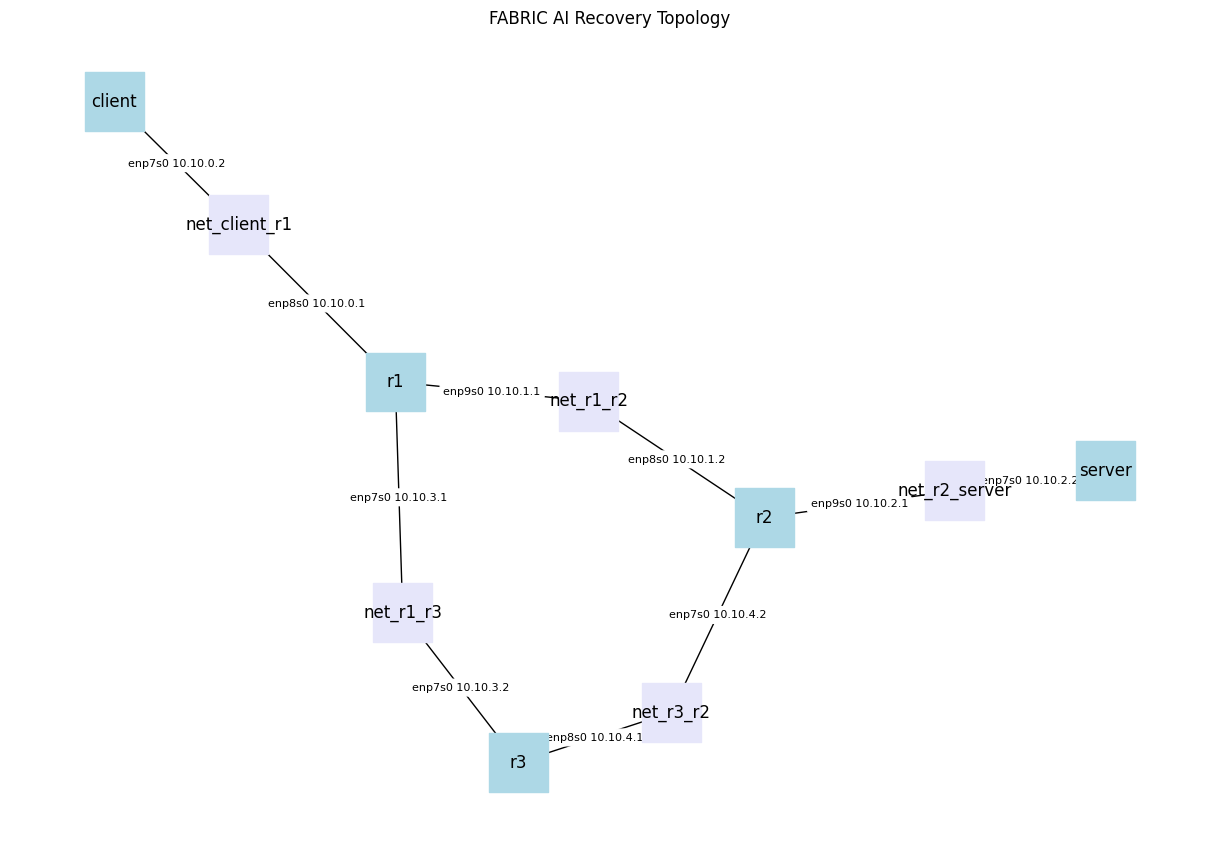

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

l2_nets = [(n.get_name(), {'color': 'lavender'}) for n in slice.get_l2networks()]
hosts = [(n.get_name(), {'color': 'lightblue'}) for n in slice.get_nodes()]
nodes = l2_nets + hosts
ifaces = [iface.toDict() for iface in slice.get_interfaces()]
edges = [(iface['network'], iface['node'], {'label': iface['physical_dev'] + ' ' + str(iface.get('ip_addr', ''))}) for iface in ifaces]

plt.figure(figsize=(12, 8))
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=3)
nx.draw(G, pos, node_shape='s', node_color=[n[1]['color'] for n in nodes], node_size=1800, with_labels=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G,'label'), font_size=8, rotate=False)
plt.title("FABRIC AI Recovery Topology")
plt.show()

## 7. Monitoring tools

The agent uses three measurements:

1. End-to-end ping from `client` to `server`.
2. `iperf3` throughput from `client` to `server`.
3. Direct-link probe from `r1` to `r2` on `10.10.1.2`, which checks whether the direct route is healthy even while user traffic is on the backup path.

In [13]:
def parse_ping(text):
    loss = 100.0
    avg = 999.0
    m_loss = re.search(r'(\d+(?:\.\d+)?)% packet loss', text)
    if m_loss:
        loss = float(m_loss.group(1))
    m_avg = re.search(r'rtt min/avg/max/(?:mdev|stddev) = [\d\.]+/([\d\.]+)/', text)
    if m_avg:
        avg = float(m_avg.group(1))
    return {"avg_rtt_ms": avg, "loss_pct": loss, "raw": text}

def measure_ping(src, dst_ip, count=8, interval=0.2):
    out, err = run(src, f"ping -c {count} -i {interval} {dst_ip}", quiet=True)
    return parse_ping(out + err)

def start_iperf_server():
    # Kill any old server, then start a new daemonized iperf3 server.
    run("server", "sudo pkill -f 'iperf3 -s' || true", quiet=True)
    run("server", "iperf3 -s -D", quiet=True)
    time.sleep(1)
    print("iperf3 server running on server")

def measure_iperf(duration=4):
    out, err = run("client", f"iperf3 -c {SERVER_IP} -t {duration} -J", quiet=True)
    txt = out + err
    try:
        data = json.loads(txt)
        bps = data.get("end", {}).get("sum_received", {}).get("bits_per_second", None)
        if bps is None:
            bps = data.get("end", {}).get("sum_sent", {}).get("bits_per_second", 0)
        return {"throughput_mbps": bps / 1e6, "raw": txt}
    except Exception:
        return {"throughput_mbps": 0.0, "raw": txt}

def observe_network(current_path, direct_healthy_streak):
    e2e = measure_ping("client", SERVER_IP)
    direct_probe = measure_ping("r1", R2_DIRECT_IP)
    thr = measure_iperf(duration=3)
    obs = Observation(
        current_path_backup=1 if current_path == "backup" else 0,
        e2e_rtt_ms=e2e["avg_rtt_ms"],
        e2e_loss_pct=e2e["loss_pct"],
        throughput_mbps=thr["throughput_mbps"],
        direct_probe_rtt_ms=direct_probe["avg_rtt_ms"],
        direct_probe_loss_pct=direct_probe["loss_pct"],
        direct_healthy_streak=direct_healthy_streak
    )
    return obs, {"e2e": e2e, "direct_probe": direct_probe, "throughput": thr}

start_iperf_server()
print("Testing baseline connectivity...")
print(measure_ping("client", SERVER_IP))

iperf3 server running on server
Testing baseline connectivity...
{'avg_rtt_ms': 0.377, 'loss_pct': 0.0, 'raw': 'PING 10.10.2.2 (10.10.2.2) 56(84) bytes of data.\n64 bytes from 10.10.2.2: icmp_seq=1 ttl=62 time=1.49 ms\n64 bytes from 10.10.2.2: icmp_seq=2 ttl=62 time=0.194 ms\n64 bytes from 10.10.2.2: icmp_seq=3 ttl=62 time=0.189 ms\n64 bytes from 10.10.2.2: icmp_seq=4 ttl=62 time=0.179 ms\n64 bytes from 10.10.2.2: icmp_seq=5 ttl=62 time=0.173 ms\n64 bytes from 10.10.2.2: icmp_seq=6 ttl=62 time=0.206 ms\n64 bytes from 10.10.2.2: icmp_seq=7 ttl=62 time=0.236 ms\n64 bytes from 10.10.2.2: icmp_seq=8 ttl=62 time=0.356 ms\n\n--- 10.10.2.2 ping statistics ---\n8 packets transmitted, 8 received, 0% packet loss, time 1423ms\nrtt min/avg/max/mdev = 0.173/0.377/1.489/0.423 ms\n'}


## 8. Congestion simulation tools

The bad condition is simulated by adding delay/loss to the direct `r1 <-> r2` link. The link is not fully down. It is just slower and lossy, which is better for showing performance-aware routing instead of simple failure recovery.

In [14]:
def get_dev(node_name, net_name):
    iface_name = f"{node_name}-{net_name}-p1"
    return slice.get_interface(iface_name).get_device_name()

R1_R2_DEV_R1 = get_dev("r1", "net_r1_r2")
R1_R2_DEV_R2 = get_dev("r2", "net_r1_r2")
print("r1 device on r1-r2 link:", R1_R2_DEV_R1)
print("r2 device on r1-r2 link:", R1_R2_DEV_R2)

def degrade_direct_link(delay_ms=80, loss_pct=5):
    # Apply in both directions because ping/iperf traffic has request and response packets.
    run("r1", f"sudo tc qdisc replace dev {R1_R2_DEV_R1} root netem delay {delay_ms}ms loss {loss_pct}%")
    run("r2", f"sudo tc qdisc replace dev {R1_R2_DEV_R2} root netem delay {delay_ms}ms loss {loss_pct}%")
    print(f"Direct r1<->r2 link degraded: delay={delay_ms}ms, loss={loss_pct}%")

def recover_direct_link():
    run("r1", f"sudo tc qdisc del dev {R1_R2_DEV_R1} root || true", quiet=True)
    run("r2", f"sudo tc qdisc del dev {R1_R2_DEV_R2} root || true", quiet=True)
    print("Direct r1<->r2 link recovered: netem removed")

# Start clean.
recover_direct_link()

r1 device on r1-r2 link: enp9s0
r2 device on r1-r2 link: enp8s0
Direct r1<->r2 link recovered: netem removed


## 9. Train the local lightweight AI agent

The model is trained locally using synthetic network examples. The synthetic labels represent the policy we want the agent to learn:

- If the direct path is bad, switch to backup.
- If currently on backup, keep using backup until the direct link is healthy for multiple checks.
- If the direct link is stably healthy again, restore direct route.

At runtime, the control loop uses model prediction, not manual if/else decision code.

In [27]:
# ============================================================
# Improved data collection + automatic labeling + retraining
# More realistic version:
# - random direct-path congestion
# - gradual degradation/recovery
# - backup path can also degrade on r1-r3, r3-r2, or both
# - teacher policy compares direct vs backup path quality
# - switching margin prevents route flapping
# ============================================================

import random
import time
import joblib
import numpy as np
import pandas as pd

from pathlib import Path
from dataclasses import dataclass

from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Extra IP constants for backup-path probing
# ------------------------------------------------------------

R3_FROM_R1_IP = "10.10.3.2"   # r3 address on r1-r3 link
R2_FROM_R3_IP = "10.10.4.2"   # r2 address on r3-r2 link

# ------------------------------------------------------------
# Devices for backup links
# ------------------------------------------------------------

R1_R3_DEV_R1 = get_dev("r1", "net_r1_r3")
R1_R3_DEV_R3 = get_dev("r3", "net_r1_r3")

R3_R2_DEV_R3 = get_dev("r3", "net_r3_r2")
R3_R2_DEV_R2 = get_dev("r2", "net_r3_r2")

print("Backup r1-r3 devices:", R1_R3_DEV_R1, R1_R3_DEV_R3)
print("Backup r3-r2 devices:", R3_R2_DEV_R3, R3_R2_DEV_R2)

# ------------------------------------------------------------
# Netem helpers
# ------------------------------------------------------------

def set_netem_pair(node_a, dev_a, node_b, dev_b, delay_ms=0, loss_pct=0):
    """
    Apply netem to both directions of one logical link.
    If delay/loss are both 0, remove netem.
    """
    delay_ms = max(0, float(delay_ms))
    loss_pct = max(0, float(loss_pct))

    if delay_ms <= 0 and loss_pct <= 0:
        run(node_a, f"sudo tc qdisc del dev {dev_a} root || true", quiet=True)
        run(node_b, f"sudo tc qdisc del dev {dev_b} root || true", quiet=True)
    else:
        run(node_a, f"sudo tc qdisc replace dev {dev_a} root netem delay {delay_ms:.1f}ms loss {loss_pct:.2f}%")
        run(node_b, f"sudo tc qdisc replace dev {dev_b} root netem delay {delay_ms:.1f}ms loss {loss_pct:.2f}%")

def set_direct_impairment(delay_ms=0, loss_pct=0):
    set_netem_pair("r1", R1_R2_DEV_R1, "r2", R1_R2_DEV_R2, delay_ms, loss_pct)

def set_backup_r1r3_impairment(delay_ms=0, loss_pct=0):
    set_netem_pair("r1", R1_R3_DEV_R1, "r3", R1_R3_DEV_R3, delay_ms, loss_pct)

def set_backup_r3r2_impairment(delay_ms=0, loss_pct=0):
    set_netem_pair("r3", R3_R2_DEV_R3, "r2", R3_R2_DEV_R2, delay_ms, loss_pct)

def clear_all_netem():
    set_direct_impairment(0, 0)
    set_backup_r1r3_impairment(0, 0)
    set_backup_r3r2_impairment(0, 0)

# ------------------------------------------------------------
# Extended observation
# ------------------------------------------------------------

@dataclass
class ExtendedObservation:
    current_path_backup: int

    e2e_rtt_ms: float
    e2e_loss_pct: float
    throughput_mbps: float

    direct_probe_rtt_ms: float
    direct_probe_loss_pct: float

    backup_probe_rtt_ms: float
    backup_probe_loss_pct: float

    direct_score: float
    backup_score: float
    score_delta: float

    direct_healthy_streak: int
    backup_healthy_streak: int

    def as_array(self):
        return np.array([[
            self.current_path_backup,
            self.e2e_rtt_ms,
            self.e2e_loss_pct,
            self.throughput_mbps,
            self.direct_probe_rtt_ms,
            self.direct_probe_loss_pct,
            self.backup_probe_rtt_ms,
            self.backup_probe_loss_pct,
            self.direct_score,
            self.backup_score,
            self.score_delta,
            self.direct_healthy_streak,
            self.backup_healthy_streak
        ]], dtype=float)

FEATURE_COLS = [
    "current_path_backup",
    "e2e_rtt_ms",
    "e2e_loss_pct",
    "throughput_mbps",
    "direct_probe_rtt_ms",
    "direct_probe_loss_pct",
    "backup_probe_rtt_ms",
    "backup_probe_loss_pct",
    "direct_score",
    "backup_score",
    "score_delta",
    "direct_healthy_streak",
    "backup_healthy_streak"
]

# ------------------------------------------------------------
# Score + probing helpers
# ------------------------------------------------------------

LOSS_WEIGHT = 20.0
SWITCH_MARGIN = 25.0
RESTORE_STREAK_REQUIRED = 3

def path_score(rtt_ms, loss_pct):
    """
    Lower score is better.
    Loss is heavily penalized because packet loss hurts TCP/iperf performance.
    """
    return float(rtt_ms) + LOSS_WEIGHT * float(loss_pct)

def combine_loss(loss_a, loss_b):
    """
    Combine two independent loss percentages for the two backup links.
    """
    success_a = 1.0 - float(loss_a) / 100.0
    success_b = 1.0 - float(loss_b) / 100.0
    return 100.0 * (1.0 - success_a * success_b)

def fast_observe_tradeoff_network(current_path, direct_healthy_streak, backup_healthy_streak):
    """
    Collect live FABRIC measurements.

    Direct path probe:
        r1 -> r2 on net_r1_r2

    Backup path probe:
        r1 -> r3 and r3 -> r2, then combine them
    """
    e2e = measure_ping("client", SERVER_IP, count=4, interval=0.1)

    direct_probe = measure_ping("r1", R2_DIRECT_IP, count=4, interval=0.1)

    backup_probe_1 = measure_ping("r1", R3_FROM_R1_IP, count=4, interval=0.1)
    backup_probe_2 = measure_ping("r3", R2_FROM_R3_IP, count=4, interval=0.1)

    thr = measure_iperf(duration=1)

    backup_rtt = backup_probe_1["avg_rtt_ms"] + backup_probe_2["avg_rtt_ms"]
    backup_loss = combine_loss(backup_probe_1["loss_pct"], backup_probe_2["loss_pct"])

    direct_score = path_score(direct_probe["avg_rtt_ms"], direct_probe["loss_pct"])
    backup_score = path_score(backup_rtt, backup_loss)
    score_delta = direct_score - backup_score
    # positive score_delta means backup is better
    # negative score_delta means direct is better

    obs = ExtendedObservation(
        current_path_backup=1 if current_path == "backup" else 0,

        e2e_rtt_ms=e2e["avg_rtt_ms"],
        e2e_loss_pct=e2e["loss_pct"],
        throughput_mbps=thr["throughput_mbps"],

        direct_probe_rtt_ms=direct_probe["avg_rtt_ms"],
        direct_probe_loss_pct=direct_probe["loss_pct"],

        backup_probe_rtt_ms=backup_rtt,
        backup_probe_loss_pct=backup_loss,

        direct_score=direct_score,
        backup_score=backup_score,
        score_delta=score_delta,

        direct_healthy_streak=direct_healthy_streak,
        backup_healthy_streak=backup_healthy_streak
    )

    return obs

def update_tradeoff_streaks(obs, direct_streak, backup_streak):
    direct_good = (obs.direct_probe_loss_pct < 2.0) and (obs.direct_score < 35.0)
    backup_good = (obs.backup_probe_loss_pct < 2.0) and (obs.backup_score < 45.0)

    direct_streak = direct_streak + 1 if direct_good else 0
    backup_streak = backup_streak + 1 if backup_good else 0

    return direct_streak, backup_streak

# ------------------------------------------------------------
# Teacher labeling policy with switching cost / hysteresis
# ------------------------------------------------------------

def teacher_label_tradeoff(obs, current_path):
    """
    Teacher policy that creates labels from real measurements.

    Main idea:
    - Do not switch just because the other path is slightly better.
    - Switch only when the other path is better by SWITCH_MARGIN.
    - Restore direct only when direct is clearly better and stable.
    """
    backup_clearly_better = obs.backup_score + SWITCH_MARGIN < obs.direct_score
    direct_clearly_better = obs.direct_score + SWITCH_MARGIN < obs.backup_score

    if current_path == "direct":
        if backup_clearly_better:
            return "SWITCH_TO_BACKUP"
        return "KEEP_DIRECT"

    if current_path == "backup":
        if direct_clearly_better and obs.direct_healthy_streak >= RESTORE_STREAK_REQUIRED:
            return "RESTORE_DIRECT"
        return "KEEP_BACKUP"

    raise ValueError("Unknown current_path")

# ------------------------------------------------------------
# Gradual scenario generation
# ------------------------------------------------------------

def ramp_value(round_id, start_round, peak_round, recover_round, end_round, max_value):
    """
    Creates gradual bad->worse->better behavior.

    0 before start_round.
    Gradually ramps up until peak_round.
    Stays near max until recover_round.
    Gradually ramps down until end_round.
    0 after end_round.
    """
    if round_id < start_round:
        return 0.0

    if start_round <= round_id <= peak_round:
        denom = max(1, peak_round - start_round + 1)
        return max_value * ((round_id - start_round + 1) / denom)

    if peak_round < round_id < recover_round:
        return float(max_value)

    if recover_round <= round_id <= end_round:
        denom = max(1, end_round - recover_round + 1)
        return max_value * (1.0 - ((round_id - recover_round + 1) / denom))

    return 0.0

def make_random_scenario(rounds_per_cycle):
    """
    Creates one randomized cycle.

    Direct path:
      healthy -> gradually bad -> bad -> gradually recovered

    Backup path:
      may be clean, mildly degraded, or also changing
    """
    direct_start = random.randint(3, 6)
    direct_peak = direct_start + random.randint(1, 3)
    direct_recover = random.randint(direct_peak + 3, min(rounds_per_cycle - 4, direct_peak + 7))
    direct_end = min(rounds_per_cycle, direct_recover + random.randint(2, 4))

    direct_max_delay = random.choice([30, 50, 70, 90, 120])
    direct_max_loss = random.choice([1, 2, 3, 5, 8])

    backup_target = random.choice(["none", "r1r3", "r3r2", "both"])

    # Backup path can degrade at a different time and with different strength.
    backup_start = random.randint(4, 9)
    backup_peak = backup_start + random.randint(1, 3)
    backup_recover = random.randint(backup_peak + 3, min(rounds_per_cycle - 3, backup_peak + 8))
    backup_end = min(rounds_per_cycle, backup_recover + random.randint(2, 4))

    # Usually backup degradation is milder, but sometimes it is meaningful.
    backup_max_delay = random.choice([0, 10, 20, 35, 50, 70])
    backup_max_loss = random.choice([0, 0, 1, 2, 3, 5])

    return {
        "direct_start": direct_start,
        "direct_peak": direct_peak,
        "direct_recover": direct_recover,
        "direct_end": direct_end,
        "direct_max_delay": direct_max_delay,
        "direct_max_loss": direct_max_loss,

        "backup_target": backup_target,
        "backup_start": backup_start,
        "backup_peak": backup_peak,
        "backup_recover": backup_recover,
        "backup_end": backup_end,
        "backup_max_delay": backup_max_delay,
        "backup_max_loss": backup_max_loss
    }

def apply_scenario_round(scenario, round_id):
    """
    Apply direct and backup impairments for the current round.
    """
    direct_delay = ramp_value(
        round_id,
        scenario["direct_start"],
        scenario["direct_peak"],
        scenario["direct_recover"],
        scenario["direct_end"],
        scenario["direct_max_delay"]
    )

    direct_loss = ramp_value(
        round_id,
        scenario["direct_start"],
        scenario["direct_peak"],
        scenario["direct_recover"],
        scenario["direct_end"],
        scenario["direct_max_loss"]
    )

    backup_delay = ramp_value(
        round_id,
        scenario["backup_start"],
        scenario["backup_peak"],
        scenario["backup_recover"],
        scenario["backup_end"],
        scenario["backup_max_delay"]
    )

    backup_loss = ramp_value(
        round_id,
        scenario["backup_start"],
        scenario["backup_peak"],
        scenario["backup_recover"],
        scenario["backup_end"],
        scenario["backup_max_loss"]
    )

    set_direct_impairment(direct_delay, direct_loss)

    target = scenario["backup_target"]

    if target == "none":
        set_backup_r1r3_impairment(0, 0)
        set_backup_r3r2_impairment(0, 0)
    elif target == "r1r3":
        set_backup_r1r3_impairment(backup_delay, backup_loss)
        set_backup_r3r2_impairment(0, 0)
    elif target == "r3r2":
        set_backup_r1r3_impairment(0, 0)
        set_backup_r3r2_impairment(backup_delay, backup_loss)
    elif target == "both":
        set_backup_r1r3_impairment(backup_delay, backup_loss)
        set_backup_r3r2_impairment(backup_delay, backup_loss)

    return {
        "direct_delay_setting_ms": direct_delay,
        "direct_loss_setting_pct": direct_loss,
        "backup_delay_setting_ms": backup_delay,
        "backup_loss_setting_pct": backup_loss,
        "backup_target": target
    }

# ------------------------------------------------------------
# Improved agent wrapper
# ------------------------------------------------------------

class TradeoffNetworkAIAgent:
    def __init__(self, model=None, feature_cols=None):
        self.model = model
        self.feature_cols = feature_cols or FEATURE_COLS
        self.is_trained = model is not None

    def predict(self, obs):
        if not self.is_trained:
            raise RuntimeError("Agent must be trained first.")

        X = obs.as_array()
        action = self.model.predict(X)[0]

        proba = {}
        if hasattr(self.model[-1], "classes_"):
            probs = self.model.predict_proba(X)[0]
            proba = dict(zip(self.model[-1].classes_, probs))

        return action, proba

# ------------------------------------------------------------
# Data collection
# ------------------------------------------------------------

def collect_training_data_tradeoff(num_cycles=30, rounds_per_cycle=20):
    """
    Collects real FABRIC measurements using naturalized scenarios.

    30 cycles x 20 rounds = about 600 rows.
    """
    all_rows = []

    start_iperf_server()

    for cycle_id in range(1, num_cycles + 1):
        print(f"\n================ CYCLE {cycle_id}/{num_cycles} ================")

        clear_all_netem()
        apply_route_mode("direct")

        current_path = "direct"
        direct_healthy_streak = 0
        backup_healthy_streak = 0

        scenario = make_random_scenario(rounds_per_cycle)
        print("Scenario:", scenario)

        for round_id in range(1, rounds_per_cycle + 1):
            print(f"Cycle {cycle_id}, Round {round_id}")

            settings = apply_scenario_round(scenario, round_id)

            obs = fast_observe_tradeoff_network(
                current_path=current_path,
                direct_healthy_streak=direct_healthy_streak,
                backup_healthy_streak=backup_healthy_streak
            )

            direct_healthy_streak, backup_healthy_streak = update_tradeoff_streaks(
                obs,
                direct_healthy_streak,
                backup_healthy_streak
            )

            # Repack with updated streaks.
            obs = ExtendedObservation(
                current_path_backup=obs.current_path_backup,

                e2e_rtt_ms=obs.e2e_rtt_ms,
                e2e_loss_pct=obs.e2e_loss_pct,
                throughput_mbps=obs.throughput_mbps,

                direct_probe_rtt_ms=obs.direct_probe_rtt_ms,
                direct_probe_loss_pct=obs.direct_probe_loss_pct,

                backup_probe_rtt_ms=obs.backup_probe_rtt_ms,
                backup_probe_loss_pct=obs.backup_probe_loss_pct,

                direct_score=obs.direct_score,
                backup_score=obs.backup_score,
                score_delta=obs.score_delta,

                direct_healthy_streak=direct_healthy_streak,
                backup_healthy_streak=backup_healthy_streak
            )

            label = teacher_label_tradeoff(obs, current_path)

            old_path = current_path
            current_path = execute_agent_action(label, current_path)

            row = {
                "cycle": cycle_id,
                "round": round_id,

                "path_before": old_path,
                "label": label,
                "path_after": current_path,

                "current_path_backup": obs.current_path_backup,

                "e2e_rtt_ms": obs.e2e_rtt_ms,
                "e2e_loss_pct": obs.e2e_loss_pct,
                "throughput_mbps": obs.throughput_mbps,

                "direct_probe_rtt_ms": obs.direct_probe_rtt_ms,
                "direct_probe_loss_pct": obs.direct_probe_loss_pct,

                "backup_probe_rtt_ms": obs.backup_probe_rtt_ms,
                "backup_probe_loss_pct": obs.backup_probe_loss_pct,

                "direct_score": obs.direct_score,
                "backup_score": obs.backup_score,
                "score_delta": obs.score_delta,

                "direct_healthy_streak": obs.direct_healthy_streak,
                "backup_healthy_streak": obs.backup_healthy_streak,

                "switch_margin": SWITCH_MARGIN,
                "loss_weight": LOSS_WEIGHT,

                **settings,
                **scenario
            }

            all_rows.append(row)
            print(pd.Series(row))

            time.sleep(1)

    clear_all_netem()
    apply_route_mode("direct")

    df = pd.DataFrame(all_rows)

    csv_path = DATA_DIR / "fabric_training_data_tradeoff.csv"
    df.to_csv(csv_path, index=False)

    print(f"\nSaved improved training data to: {csv_path}")
    print("Dataset shape:", df.shape)
    print("\nLabel counts:")
    print(df["label"].value_counts())

    return df

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

def train_tradeoff_agent_from_fabric_data(df):
    """
    Trains and compares lightweight local AI models using the improved dataset.
    """
    X = df[FEATURE_COLS].values
    y = df["label"].values

    # Stratify only when every class has enough samples.
    label_counts = df["label"].value_counts()
    stratify_arg = y if label_counts.min() >= 2 else None

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=7,
        stratify=stratify_arg
    )

    models = {
        "DecisionTree": DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=5,
            random_state=7
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=150,
            max_depth=8,
            min_samples_leaf=5,
            random_state=7
        ),
        "GradientBoosting": GradientBoostingClassifier(
            random_state=7
        )
    }

    results = {}

    for name, clf in models.items():
        pipe = Pipeline([
            ("scale", StandardScaler()),
            ("model", clf)
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        acc = accuracy_score(y_test, pred)

        results[name] = {
            "model": pipe,
            "accuracy": acc
        }

        print(f"\n===== {name} =====")
        print("Accuracy:", round(acc, 4))
        print(classification_report(y_test, pred))

    best_name = max(results, key=lambda k: results[k]["accuracy"])
    best_model = results[best_name]["model"]

    print(f"\nBest model: {best_name}")
    print("Best accuracy:", round(results[best_name]["accuracy"], 4))

    improved_agent = TradeoffNetworkAIAgent(
        model=best_model,
        feature_cols=FEATURE_COLS
    )
    improved_agent.is_trained = True

    joblib.dump(improved_agent, "improved_fabric_tradeoff_ai_agent.joblib")

    print("Saved improved tradeoff agent to improved_fabric_tradeoff_ai_agent.joblib")

    return improved_agent, results

# ------------------------------------------------------------
# Run improved collection and retraining
# ------------------------------------------------------------

training_df = collect_training_data_tradeoff(
    num_cycles=30,
    rounds_per_cycle=20
)

improved_agent, model_results = train_tradeoff_agent_from_fabric_data(training_df)

# Replace notebook agent with the improved tradeoff-aware model.
agent = improved_agent

print("Current notebook agent replaced with improved tradeoff-aware AI agent.")

Backup r1-r3 devices: enp7s0 enp7s0
Backup r3-r2 devices: enp8s0 enp7s0
iperf3 server running on server

================ CYCLE 1/30 ================
Route mode applied: direct
Scenario: {'direct_start': 5, 'direct_peak': 6, 'direct_recover': 9, 'direct_end': 12, 'direct_max_delay': 50, 'direct_max_loss': 2, 'backup_target': 'both', 'backup_start': 8, 'backup_peak': 11, 'backup_recover': 17, 'backup_end': 20, 'backup_max_delay': 20, 'backup_max_loss': 1}
Cycle 1, Round 1
cycle                                 1
round                                 1
path_before                      direct
label                       KEEP_DIRECT
path_after                       direct
current_path_backup                   0
e2e_rtt_ms                        0.367
e2e_loss_pct                        0.0
throughput_mbps            15795.276638
direct_probe_rtt_ms               0.195
direct_probe_loss_pct               0.0
backup_probe_rtt_ms               0.321
backup_probe_loss_pct               0.0
dire

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



===== GradientBoosting =====
Accuracy: 0.9933
                  precision    recall  f1-score   support

     KEEP_BACKUP       1.00      1.00      1.00        95
     KEEP_DIRECT       0.98      1.00      0.99        45
  RESTORE_DIRECT       1.00      1.00      1.00         3
SWITCH_TO_BACKUP       1.00      0.86      0.92         7

        accuracy                           0.99       150
       macro avg       0.99      0.96      0.98       150
    weighted avg       0.99      0.99      0.99       150


Best model: DecisionTree
Best accuracy: 0.9933
Saved improved tradeoff agent to improved_fabric_tradeoff_ai_agent.joblib
Current notebook agent replaced with improved tradeoff-aware AI agent.


## 10. Closed-loop experiment

This is the main experiment.

Flow:

```text
Round 1-2: direct path healthy
Round 3: degrade r1<->r2
Agent should switch to backup
Round 7: recover r1<->r2
Agent should wait for stable healthy probes
Then agent restores direct path
```

In [29]:
# ============================================================
# Final simulation using the improved tradeoff-aware AI agent
# ============================================================

def execute_agent_action(action, current_path):
    if action == "SWITCH_TO_BACKUP" and current_path != "backup":
        apply_route_mode("backup")
        return "backup"

    if action == "RESTORE_DIRECT" and current_path != "direct":
        apply_route_mode("direct")
        return "direct"

    return current_path


# Make sure experiment starts clean.
clear_all_netem()
apply_route_mode("direct")
start_iperf_server()

current_path = "direct"
direct_healthy_streak = 0
backup_healthy_streak = 0
history = []

for round_id in range(1, 21):
    print(f"===== ROUND {round_id} =====")

    # --------------------------------------------------------
    # Final test scenario:
    # Direct path gradually gets worse, then gradually recovers.
    # Backup path also has a small temporary quality change.
    # --------------------------------------------------------

    # Direct path starts to degrade.
    if round_id == 5:
        set_direct_impairment(delay_ms=50, loss_pct=2)
    
    # Direct path gets worse.
    if round_id == 8:
        set_direct_impairment(delay_ms=80, loss_pct=4)
    
    # Direct path partially recovers.
    if round_id == 12:
        set_direct_impairment(delay_ms=30, loss_pct=1)
    
    # Direct path fully recovers.
    if round_id == 14:
        set_direct_impairment(delay_ms=0, loss_pct=0)
    
    # Backup path becomes worse AFTER direct recovers.
    # This should encourage RESTORE_DIRECT.
    if round_id == 15:
        set_backup_r1r3_impairment(delay_ms=40, loss_pct=2)
    
    # Keep backup bad for a few rounds.
    # Then clear it later.
    if round_id == 19:
        set_backup_r1r3_impairment(delay_ms=0, loss_pct=0)

    # --------------------------------------------------------
    # Observe both direct path and backup path quality.
    # --------------------------------------------------------
    obs = fast_observe_tradeoff_network(
        current_path=current_path,
        direct_healthy_streak=direct_healthy_streak,
        backup_healthy_streak=backup_healthy_streak
    )

    # Update stability counters for both paths.
    direct_healthy_streak, backup_healthy_streak = update_tradeoff_streaks(
        obs,
        direct_healthy_streak,
        backup_healthy_streak
    )

    # Repack observation with updated streaks.
    obs = ExtendedObservation(
        current_path_backup=obs.current_path_backup,

        e2e_rtt_ms=obs.e2e_rtt_ms,
        e2e_loss_pct=obs.e2e_loss_pct,
        throughput_mbps=obs.throughput_mbps,

        direct_probe_rtt_ms=obs.direct_probe_rtt_ms,
        direct_probe_loss_pct=obs.direct_probe_loss_pct,

        backup_probe_rtt_ms=obs.backup_probe_rtt_ms,
        backup_probe_loss_pct=obs.backup_probe_loss_pct,

        direct_score=obs.direct_score,
        backup_score=obs.backup_score,
        score_delta=obs.score_delta,

        direct_healthy_streak=direct_healthy_streak,
        backup_healthy_streak=backup_healthy_streak
    )

    # AI decision with probability.
    action, proba = agent.predict(obs)

    old_path = current_path
    current_path = execute_agent_action(action, current_path)

    row = {
        "round": round_id,
        "path_before": old_path,
        "action": action,
        "path_after": current_path,

        "e2e_rtt_ms": obs.e2e_rtt_ms,
        "e2e_loss_pct": obs.e2e_loss_pct,
        "throughput_mbps": obs.throughput_mbps,

        "direct_probe_rtt_ms": obs.direct_probe_rtt_ms,
        "direct_probe_loss_pct": obs.direct_probe_loss_pct,

        "backup_probe_rtt_ms": obs.backup_probe_rtt_ms,
        "backup_probe_loss_pct": obs.backup_probe_loss_pct,

        "direct_score": obs.direct_score,
        "backup_score": obs.backup_score,
        "score_delta": obs.score_delta,

        "direct_healthy_streak": obs.direct_healthy_streak,
        "backup_healthy_streak": obs.backup_healthy_streak,

        "probability": {k: round(v, 3) for k, v in proba.items()}
    }

    history.append(row)
    print(pd.Series(row))
    time.sleep(2)

# Clean up after final simulation.
clear_all_netem()
apply_route_mode("direct")

results_df = pd.DataFrame(history)
results_df

Route mode applied: direct
iperf3 server running on server
===== ROUND 1 =====
round                                                                    1
path_before                                                         direct
action                                                         KEEP_DIRECT
path_after                                                          direct
e2e_rtt_ms                                                           0.398
e2e_loss_pct                                                           0.0
throughput_mbps                                               17636.845177
direct_probe_rtt_ms                                                  0.063
direct_probe_loss_pct                                                  0.0
backup_probe_rtt_ms                                                  0.426
backup_probe_loss_pct                                                  0.0
direct_score                                                         0.063
backup_score         

,round,path_before,action,path_after,e2e_rtt_ms,e2e_loss_pct,throughput_mbps,direct_probe_rtt_ms,direct_probe_loss_pct,backup_probe_rtt_ms,backup_probe_loss_pct,direct_score,backup_score,score_delta,direct_healthy_streak,backup_healthy_streak,probability
0,1,direct,KEEP_DIRECT,direct,0.398,0.0,17636.845177,0.063,0.0,0.426,0.0,0.063,0.426,-0.363,1,1,"{'KEEP_BACKUP': 0.0, 'KEEP_DIRECT': 1.0, 'REST..."
1,2,direct,KEEP_DIRECT,direct,0.216,0.0,13881.150771,0.210,0.0,0.252,0.0,0.210,0.252,-0.042,2,2,"{'KEEP_BACKUP': 0.0, 'KEEP_DIRECT': 1.0, 'REST..."
2,3,direct,KEEP_DIRECT,direct,0.505,0.0,12793.887011,0.070,0.0,0.389,0.0,0.070,0.389,-0.319,3,3,"{'KEEP_BACKUP': 0.0, 'KEEP_DIRECT': 1.0, 'REST..."
3,4,direct,KEEP_DIRECT,direct,0.207,0.0,12643.615879,0.071,0.0,0.493,0.0,0.071,0.493,-0.422,4,4,"{'KEEP_BACKUP': 0.0, 'KEEP_DIRECT': 1.0, 'REST..."
4,5,direct,SWITCH_TO_BACKUP,backup,100.371,0.0,0.871552,100.100,0.0,0.397,0.0,100.100,0.397,99.703,0,5,"{'KEEP_BACKUP': 0.0, 'KEEP_DIRECT': 0.0, 'REST..."
5,6,backup,KEEP_BACKUP,backup,0.557,0.0,15002.122286,100.110,0.0,0.155,0.0,100.110,0.155,99.955,0,6,"{'KEEP_BACKUP': 1.0, 'KEEP_DIRECT': 0.0, 'REST..."
6,7,backup,KEEP_BACKUP,backup,0.582,0.0,14298.676825,100.105,0.0,0.130,0.0,100.105,0.130,99.975,0,7,"{'KEEP_BACKUP': 1.0, 'KEEP_DIRECT': 0.0, 'REST..."
7,8,backup,KEEP_BACKUP,backup,0.480,0.0,15216.322321,160.219,0.0,0.230,0.0,160.219,0.230,159.989,0,8,"{'KEEP_BACKUP': 1.0, 'KEEP_DIRECT': 0.0, 'REST..."
8,9,backup,KEEP_BACKUP,backup,0.358,0.0,12939.750583,160.103,0.0,0.244,0.0,160.103,0.244,159.859,0,9,"{'KEEP_BACKUP': 1.0, 'KEEP_DIRECT': 0.0, 'REST..."
9,10,backup,KEEP_BACKUP,backup,0.376,0.0,13483.090625,160.256,0.0,0.200,0.0,160.256,0.200,160.056,0,10,"{'KEEP_BACKUP': 1.0, 'KEEP_DIRECT': 0.0, 'REST..."


## 11. Plot before/after results

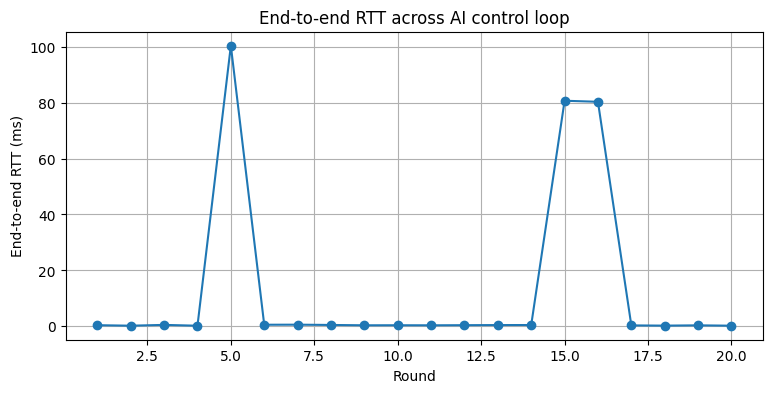

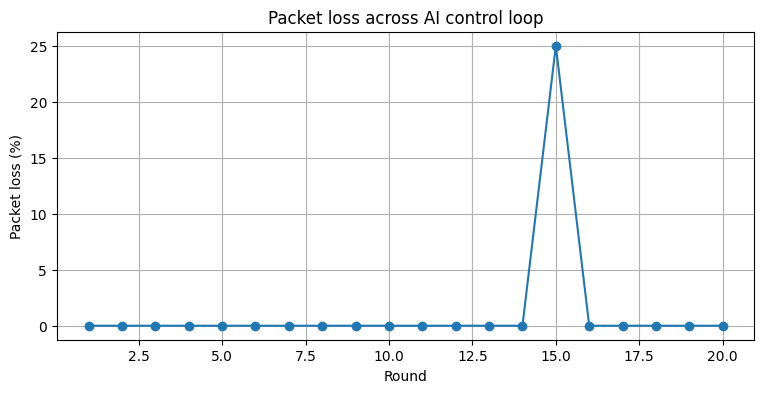

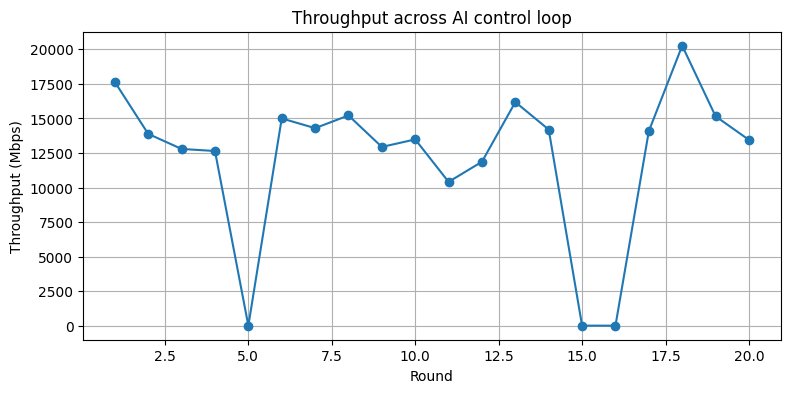

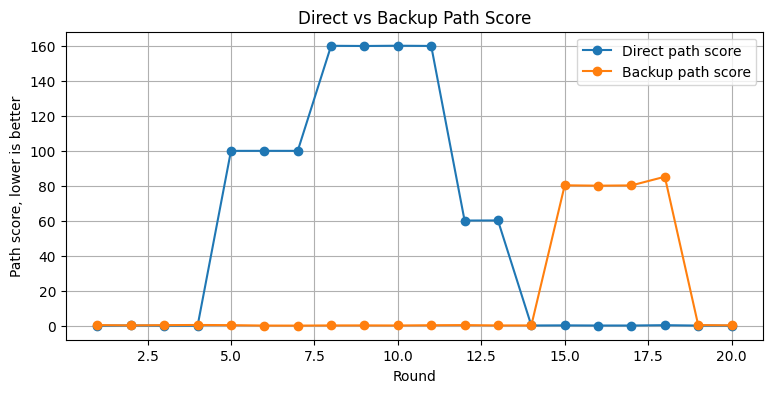

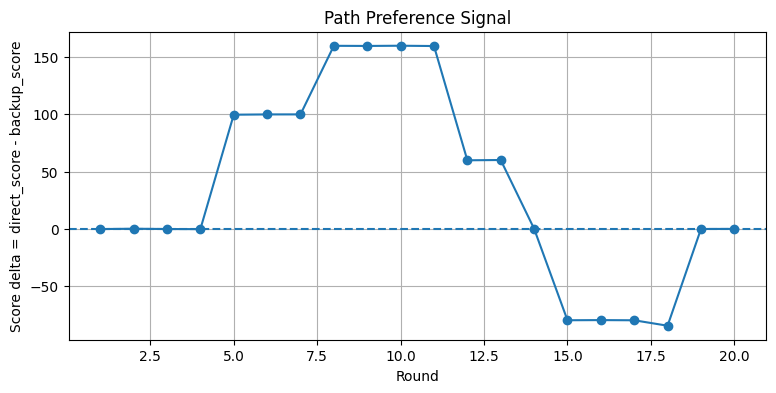

,round,path_before,action,path_after,e2e_rtt_ms,e2e_loss_pct,throughput_mbps,direct_probe_rtt_ms,direct_probe_loss_pct,backup_probe_rtt_ms,backup_probe_loss_pct,direct_score,backup_score,score_delta,direct_healthy_streak,backup_healthy_streak,probability
0,1,direct,KEEP_DIRECT,direct,0.398,0.0,17636.845177,0.063,0.0,0.426,0.0,0.063,0.426,-0.363,1,1,"{'KEEP_BACKUP': 0.0, 'KEEP_DIRECT': 1.0, 'REST..."
1,2,direct,KEEP_DIRECT,direct,0.216,0.0,13881.150771,0.210,0.0,0.252,0.0,0.210,0.252,-0.042,2,2,"{'KEEP_BACKUP': 0.0, 'KEEP_DIRECT': 1.0, 'REST..."
2,3,direct,KEEP_DIRECT,direct,0.505,0.0,12793.887011,0.070,0.0,0.389,0.0,0.070,0.389,-0.319,3,3,"{'KEEP_BACKUP': 0.0, 'KEEP_DIRECT': 1.0, 'REST..."
3,4,direct,KEEP_DIRECT,direct,0.207,0.0,12643.615879,0.071,0.0,0.493,0.0,0.071,0.493,-0.422,4,4,"{'KEEP_BACKUP': 0.0, 'KEEP_DIRECT': 1.0, 'REST..."
4,5,direct,SWITCH_TO_BACKUP,backup,100.371,0.0,0.871552,100.100,0.0,0.397,0.0,100.100,0.397,99.703,0,5,"{'KEEP_BACKUP': 0.0, 'KEEP_DIRECT': 0.0, 'REST..."
5,6,backup,KEEP_BACKUP,backup,0.557,0.0,15002.122286,100.110,0.0,0.155,0.0,100.110,0.155,99.955,0,6,"{'KEEP_BACKUP': 1.0, 'KEEP_DIRECT': 0.0, 'REST..."
6,7,backup,KEEP_BACKUP,backup,0.582,0.0,14298.676825,100.105,0.0,0.130,0.0,100.105,0.130,99.975,0,7,"{'KEEP_BACKUP': 1.0, 'KEEP_DIRECT': 0.0, 'REST..."
7,8,backup,KEEP_BACKUP,backup,0.480,0.0,15216.322321,160.219,0.0,0.230,0.0,160.219,0.230,159.989,0,8,"{'KEEP_BACKUP': 1.0, 'KEEP_DIRECT': 0.0, 'REST..."
8,9,backup,KEEP_BACKUP,backup,0.358,0.0,12939.750583,160.103,0.0,0.244,0.0,160.103,0.244,159.859,0,9,"{'KEEP_BACKUP': 1.0, 'KEEP_DIRECT': 0.0, 'REST..."
9,10,backup,KEEP_BACKUP,backup,0.376,0.0,13483.090625,160.256,0.0,0.200,0.0,160.256,0.200,160.056,0,10,"{'KEEP_BACKUP': 1.0, 'KEEP_DIRECT': 0.0, 'REST..."


In [31]:
results_df.to_csv("ai_mcp_tradeoff_results.csv", index=False)

plt.figure(figsize=(9, 4))
plt.plot(results_df["round"], results_df["e2e_rtt_ms"], marker="o")
plt.xlabel("Round")
plt.ylabel("End-to-end RTT (ms)")
plt.title("End-to-end RTT across AI control loop")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(results_df["round"], results_df["e2e_loss_pct"], marker="o")
plt.xlabel("Round")
plt.ylabel("Packet loss (%)")
plt.title("Packet loss across AI control loop")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(results_df["round"], results_df["throughput_mbps"], marker="o")
plt.xlabel("Round")
plt.ylabel("Throughput (Mbps)")
plt.title("Throughput across AI control loop")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(results_df["round"], results_df["direct_score"], marker="o", label="Direct path score")
plt.plot(results_df["round"], results_df["backup_score"], marker="o", label="Backup path score")
plt.xlabel("Round")
plt.ylabel("Path score, lower is better")
plt.title("Direct vs Backup Path Score")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(results_df["round"], results_df["score_delta"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Round")
plt.ylabel("Score delta = direct_score - backup_score")
plt.title("Path Preference Signal")
plt.grid(True)
plt.show()

results_df[
    [
        "round",
        "path_before",
        "action",
        "path_after",
        "e2e_rtt_ms",
        "e2e_loss_pct",
        "throughput_mbps",
        "direct_probe_rtt_ms",
        "direct_probe_loss_pct",
        "backup_probe_rtt_ms",
        "backup_probe_loss_pct",
        "direct_score",
        "backup_score",
        "score_delta",
        "direct_healthy_streak",
        "backup_healthy_streak",
        "probability"
    ]
]

## 12. Expected interpretation for report

Expected result:

- At first, the direct path should have low RTT and good throughput.
- After `tc netem` adds delay/loss to `r1 <-> r2`, the agent should classify the condition as bad and switch to the backup route through `r3`.
- While traffic is on the backup route, the agent still probes the direct link using `r1 -> 10.10.1.2`.
- After `tc netem` is removed, the direct-link probe becomes healthy again.
- The agent waits for several stable healthy checks, then restores the optimal direct path.

This is stronger than one-time failover because it shows closed-loop adaptive control: degrade, react, monitor recovery, and restore.

## 13. Optional: inspect SSH commands

In [32]:
pd.set_option('display.max_colwidth', None)
slice_info = [{'Name': n.get_name(), 'SSH command': n.get_ssh_command()} for n in slice.get_nodes()]
pd.DataFrame(slice_info).set_index('Name')

,SSH command
Name,
client,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:468:c00:ffc4:f816:3eff:fe76:370a
server,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:468:c00:ffc4:f816:3eff:fe5b:643c
r1,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:468:c00:ffc4:f816:3eff:fe14:a21d
r2,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:468:c00:ffc4:f816:3eff:fe70:4931
r3,ssh -i /home/fabric/work/fabric_config/slice_key -F /home/fabric/work/fabric_config/ssh_config ubuntu@2001:468:c00:ffc4:f816:3eff:fe9c:73fc


## 14. Cleanup

Only run this when the project is finished. It deletes all FABRIC resources in this slice.

In [33]:
slice = fablib.get_slice(name=slice_name)
fablib.delete_slice(slice_name)

In [36]:
# slice should end up in "Dead" state
# re-run this cell until you see it in "Dead" state
slice.update()
_ = slice.show()

ID,392a5c13-c63e-41c7-bd20-eda54a60d039
Name,ai-mcp-recovery-sonvu_0000467821
Lease Expiration (UTC),2026-05-14 15:04:20 +0000
Lease Start (UTC),2026-05-13 15:04:20 +0000
Project ID,5268932f-7bf8-4418-9dbb-1f53dcea5a6b
State,Dead
Email,sonvu@umass.edu
UserId,4ad9cab5-c698-4bba-ab3e-6da8a1abca67
